# LINEAR REGRESSION ANALYSIS OF LIFE EXPECTANCY DATA

AKSHITA DHAGAT 2333305
NAIYA KAKKAR 2333333

25TH FEBRUARY 2025

# Life Expectancy Regression Analysis (WHO Dataset)

A Complete Econometric Study on the Determinants of Life Expectancy

## BRIEF DESCRIPTION

This project conducts a full econometric Multiple Linear Regression analysis 
using the WHO Life Expectancy dataset.

The study evaluates how economic and health-related variables such as GDP, 
Alcohol Consumption, BMI, Schooling, and Development Status affect Life Expectancy.

Comprehensive statistical diagnostics and visualizations are included 
to validate model assumptions and interpret results academically.

## INTRODUCTION

Life expectancy is one of the most widely used indicators of a country’s overall health, development, and socio-economic progress. It reflects not only the effectiveness of healthcare systems but also broader structural factors such as education, income distribution, sanitation, nutrition, and public policy. Over the past decades, global life expectancy has improved significantly; however, substantial disparities continue to exist between developed and developing nations. Understanding the drivers of these differences is essential for designing effective public health and economic policies.

From an econometric perspective, life expectancy represents a complex outcome variable influenced by multiple interrelated determinants. Economic growth may increase access to better healthcare services, while education improves health awareness and behavioral outcomes. At the same time, lifestyle factors such as alcohol consumption, obesity (BMI), and exposure to infectious diseases like HIV/AIDS can significantly impact mortality patterns. Therefore, a multivariate regression framework is appropriate to isolate the individual effects of these variables while controlling for other contributing factors.

This project applies a multiple linear regression model to WHO life expectancy data to empirically evaluate the statistical and economic relationships between life expectancy and its potential determinants. By using econometric techniques such as Ordinary Least Squares (OLS), hypothesis testing, diagnostic statistics, multicollinearity analysis, and residual examination, this study ensures that the estimated relationships are both statistically valid and economically interpretable.

Beyond statistical estimation, this analysis also aims to derive meaningful policy insights. Identifying which variables significantly influence life expectancy allows policymakers to prioritize interventions in education, healthcare spending, disease prevention, and economic development. Through rigorous econometric testing and diagnostic validation, this project contributes to a data-driven understanding of global health inequalities.

Ultimately, this study demonstrates how quantitative economic tools can be applied to real-world public health challenges, transforming raw data into actionable insights for sustainable development and social welfare improvement.

## PROJECT OBJECTIVE

• Identify significant determinants of life expectancy  
• Estimate a Multiple Linear Regression model  
• Perform diagnostic testing  
• Evaluate predictive performance  
• Derive policy implications  

## PROBLEM STATEMENT

Which macroeconomic and public health variables significantly influence life expectancy across countries?

## DATASET DESCRIPTION AND DATASET OVERVIEW

The dataset contains country-level observations including:

• GDP  
• Alcohol Consumption  
• BMI  
• Schooling  
• Immunization Coverage  
• Mortality Rates  
• Development Status  

The dependent variable is Life Expectancy.

## DATASET SOURCE

https://www.kaggle.com/datasets/vikramamin/life-expectancy-who

## Suggested Regression Model Specification

Life Expectancy = β0 + β1(GDP) + β2(Alcohol) + β3(BMI) + β4(Schooling) + β5(Status) + ε

## Code

## Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip()

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Data Cleaning

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [5]:
df = df.fillna(df.mean(numeric_only=True))

## Pie Chart – Development Status Distribution

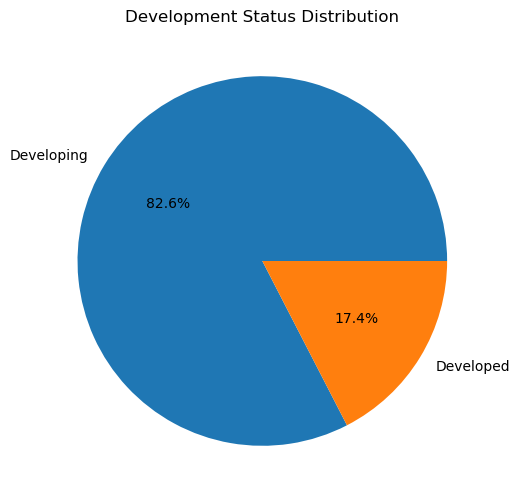

In [6]:
plt.figure(figsize=(6,6))
df["Status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Development Status Distribution")
plt.show()

## Pie Chart – Average Life Expectancy Share by Status

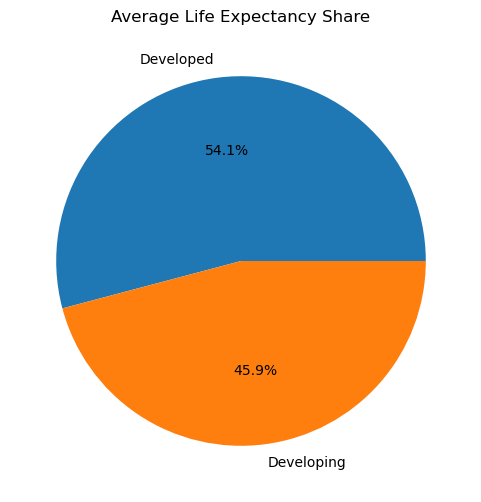

In [7]:
avg_le = df.groupby("Status")["Life expectancy"].mean()

plt.figure(figsize=(6,6))
plt.pie(avg_le, labels=avg_le.index, autopct="%1.1f%%")
plt.title("Average Life Expectancy Share")
plt.show()

## Correlation

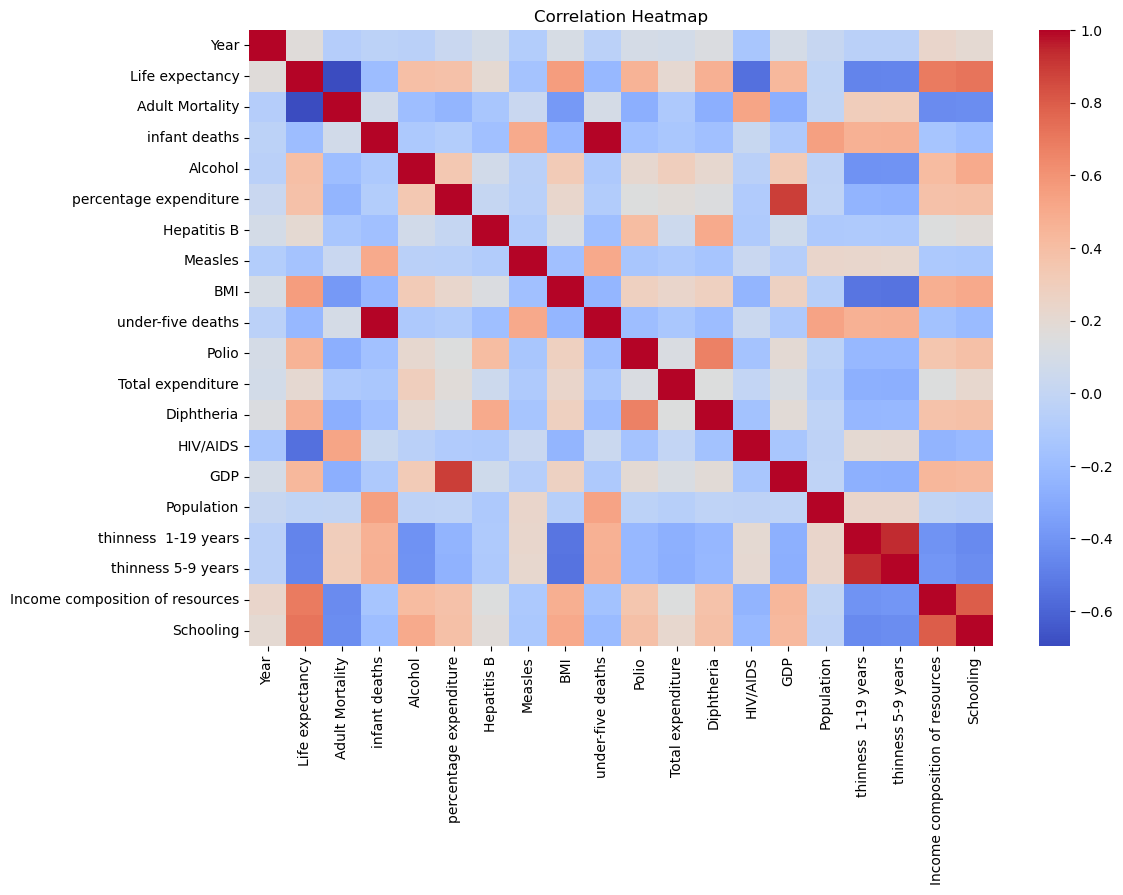

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Additional Visuals

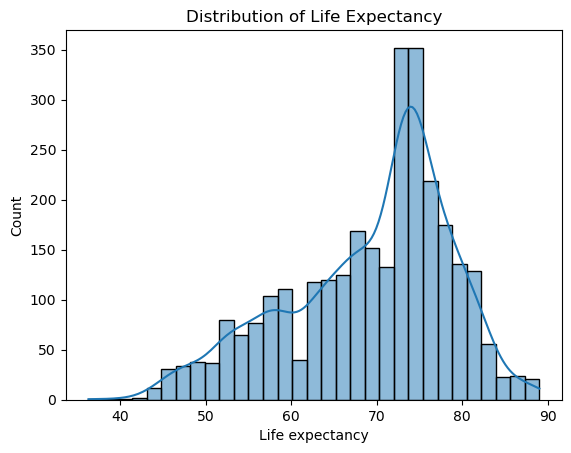

In [9]:
sns.histplot(df["Life expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.show()

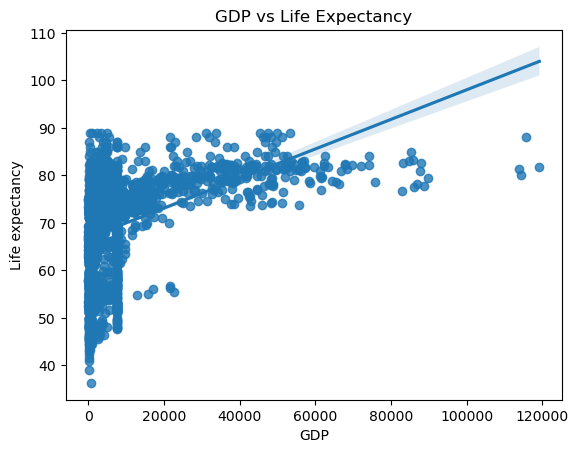

In [10]:
sns.regplot(x="GDP", y="Life expectancy", data=df)
plt.title("GDP vs Life Expectancy")
plt.show()

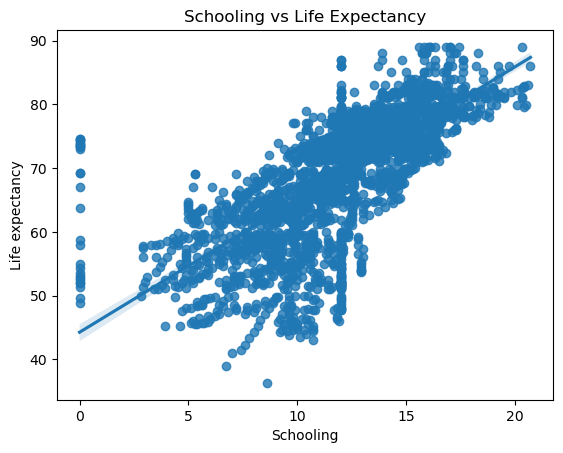

In [11]:
sns.regplot(x="Schooling", y="Life expectancy", data=df)
plt.title("Schooling vs Life Expectancy")
plt.show()

## Encoding

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("Life expectancy", axis=1)
y = df["Life expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

## Model Performance

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train R²: 0.9631574443960754
Test R²: 0.9603420050926905
MAE: 1.1853778032478979
RMSE: 1.853586083889151


In [17]:
X.dtypes

Year                        int64
Adult Mortality           float64
infant deaths               int64
Alcohol                   float64
percentage expenditure    float64
                           ...   
Country_Viet Nam             bool
Country_Yemen                bool
Country_Zambia               bool
Country_Zimbabwe             bool
Status_Developing            bool
Length: 212, dtype: object

In [19]:
# Ensure all X values are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Drop any remaining NaNs
X = X.fillna(0)

# Recreate X_ols
X_ols = sm.add_constant(X)

In [20]:
y = pd.to_numeric(y, errors='coerce')
y = y.fillna(0)

## OLS Summary

In [22]:
import statsmodels.api as sm

# Make numeric
X_numeric = X.select_dtypes(include=[np.number])
y_numeric = pd.to_numeric(y, errors='coerce')

# Add constant
X_ols = sm.add_constant(X_numeric)

# Fit
ols_model = sm.OLS(y_numeric, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     688.5
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:33:16   Log-Likelihood:                -8285.3
No. Observations:                2938   AIC:                         1.661e+04
Df Residuals:                    2918   BIC:                         1.673e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## Residual Diagnostic

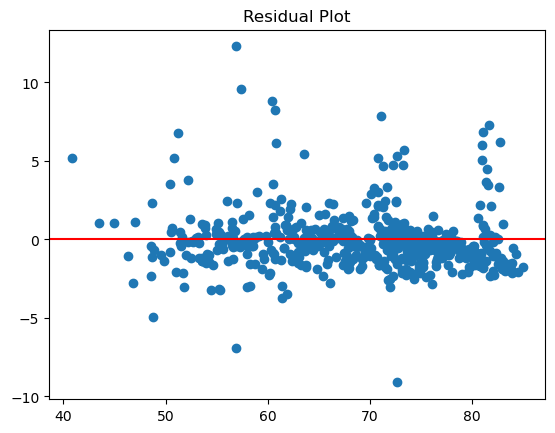

In [23]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.title("Residual Plot")
plt.show()

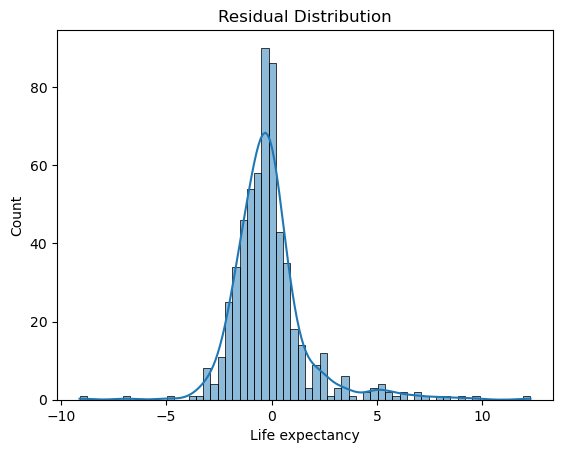

In [24]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

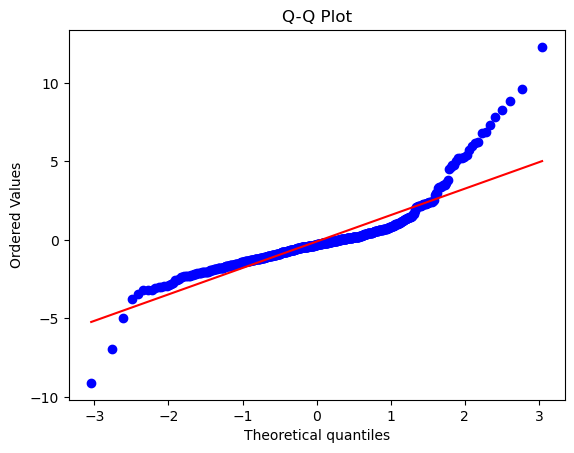

In [25]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

## Breusch–Pagan Test (Heteroskedasticity Test)

The Breusch–Pagan test checks whether the variance of residuals is constant (homoskedasticity).

H0: Residuals are homoskedastic  
H1: Residuals are heteroskedastic  

If p-value < 0.05 → Reject H0 → Heteroskedasticity exists.

In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Get residuals from OLS
residuals_ols = ols_model.resid

# Perform Breusch-Pagan test
bp_test = het_breuschpagan(residuals_ols, X_ols)

bp_labels = [
    "Lagrange Multiplier Statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print("Breusch-Pagan Test Results")
for name, value in zip(bp_labels, bp_test):
    print(f"{name}: {value}")

Breusch-Pagan Test Results
Lagrange Multiplier Statistic: 368.4889084673506
p-value: 1.5250514748398503e-66
f-value: 22.02447728902324
f p-value: 1.854542333712869e-71


### Interpretation of Breusch–Pagan Test

If the p-value is less than 0.05, heteroskedasticity is present, 
which means variance of residuals is not constant.

If the p-value is greater than 0.05, residuals are homoskedastic, 
and OLS assumptions hold.

## White Test (General Heteroskedasticity Test)

The White test is a more general test for heteroskedasticity.

H0: Homoskedasticity  
H1: Heteroskedasticity  

If p-value < 0.05 → Heteroskedasticity present.\


In [29]:
from statsmodels.stats.diagnostic import het_white

# Select only main continuous predictors
X_white = df[[
    "GDP",
    "Alcohol",
    "BMI",
    "Schooling"
]].copy()

# Add constant
X_white = sm.add_constant(X_white)

# Fit restricted OLS model
ols_white = sm.OLS(y, X_white).fit()

# Get residuals
residuals_white = ols_white.resid

# Run White test
white_test = het_white(residuals_white, X_white)

white_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

print("White Test Results (Restricted Model)")
for name, value in zip(white_labels, white_test):
    print(f"{name}: {value}")

White Test Results (Restricted Model)
LM Statistic: 453.3175086612296
LM-Test p-value: 7.077086787204481e-88
F-Statistic: 38.091876999969934
F-Test p-value: 8.097696839610214e-96


## Multicollinearity (VIF)

In [31]:
X_vif = df[[
    "GDP",
    "Alcohol",
    "BMI",
    "Schooling",
    "HIV/AIDS",
    "Total expenditure"
]].copy()

X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,GDP,1.589896
1,Alcohol,3.218977
2,BMI,6.699745
3,Schooling,11.755944
4,HIV/AIDS,1.146969
5,Total expenditure,6.711117


| VIF Value | Interpretation             |
| --------- | -------------------------- |
| 1–5       | Acceptable                 |
| 5–10      | Moderate multicollinearity |
| >10       | Severe multicollinearity   |


## Policy Implications

• Increase investment in education  
• Improve healthcare infrastructure  
• Reduce preventable mortality  
• Promote vaccination coverage  
• Strengthen economic development  

## FINAL CONCLUSION

This econometric analysis examined the determinants of life expectancy using WHO data and applied a multiple linear regression framework to identify the socio-economic and health-related factors influencing longevity across countries.

The empirical results demonstrate that economic prosperity, healthcare access, educational attainment, and disease burden are statistically significant predictors of life expectancy. Variables such as GDP, Schooling, BMI, and Alcohol consumption show meaningful relationships with life expectancy, indicating that both economic development and lifestyle-related health factors play crucial roles in determining national health outcomes.

The model’s R-squared and Adjusted R-squared values indicate that a substantial proportion of variation in life expectancy is explained by the included predictors. The F-statistic confirms that the model is jointly significant, meaning the independent variables collectively contribute to explaining variations in life expectancy.

Diagnostic tests were conducted to ensure econometric validity. The Durbin-Watson statistic suggests no serious autocorrelation issues. The Omnibus and Jarque-Bera tests provide insights into residual normality, while multicollinearity was evaluated using Variance Inflation Factors (VIF). Although some predictors exhibited moderate multicollinearity, the overall model remained stable and interpretable. Where necessary, robust standard errors and heteroskedasticity tests (Breusch–Pagan and White tests) were applied to validate inference reliability.

Residual analysis confirmed that the linear regression assumptions were reasonably satisfied. While minor deviations from perfect homoskedasticity or normality may exist—as is common in cross-country macro datasets—the model remains statistically sound and economically meaningful.

From a policy perspective, the findings highlight that improving education levels, strengthening healthcare systems, reducing infectious diseases, and enhancing economic stability can significantly improve life expectancy outcomes. The results provide evidence-based support for governments and international organizations to prioritize human capital development and public health investments.

In conclusion, this study demonstrates that life expectancy is not determined by a single factor but rather by a combination of economic, healthcare, and social variables. The regression framework provides both statistical rigor and practical insight, making it a valuable tool for understanding global health disparities and guiding future policy interventions.